## Preparing the tools
* We're going to use the `pandas`, `numpy` and `matplotlib` for data analaysis and manipulations.

In [60]:
# let's import some necessary utitlity 
import utility.graph_logic as graph_logic
import importlib
importlib.reload(graph_logic) # Relod the module when the changes are made 

# importing the library 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns 

# to appear the matplotlib graph within the notebook
%matplotlib inline

# scikit learn Model's
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# model evaluation 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve

## Load the data  

In [2]:
# let's get our data 
file_path = "../data/heart-disease.csv"
df = pd.read_csv(file_path)

In [3]:
df.shape # (rows, shape)

(303, 14)

## Data Exploration (EDA/Exploratary data analysis)

The goal here is to find out the more about the data and become a subject matter report on the dataset you are working with.

1. What question are you trying to solve?
2. What type of the data do we have and how do we treat different types?
3. What is missing from the data and How we deal with them?
4. What are the outlier's ad why should we care for them?
5. How can you add, change or remove fature to get more out of the data?

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
# How mny each classes are 
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

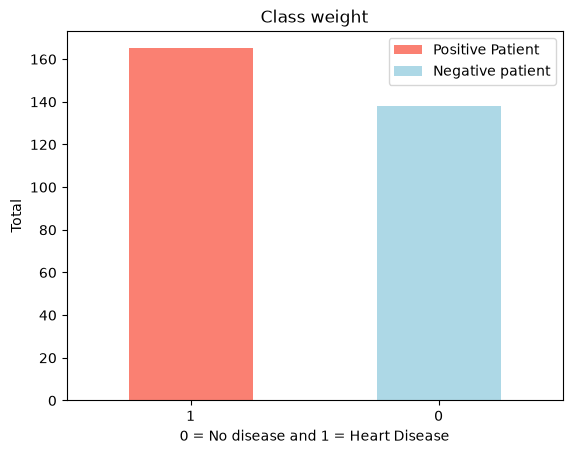

In [73]:
# plotting it for better visualization.

x_data = df.target.value_counts()

legend_handles=[
    Patch(facecolor="salmon", label="Positive Patient"),
    Patch(facecolor="lightblue", label="Negative patient"),
]

graph_logic.bar_plot(x_data=x_data,
                    graph_title="Class weight",
                    x_label="0 = No disease and 1 = Heart Disease",
                    y_label="Total",
                    labels=legend_handles,
                    colors=["salmon", "lightblue"],
                    file_name_to_save="../images/eda/001_class_weight_graph.png")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
# How many mising value 
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
# let's find the pattern 
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [12]:
# compare the target column with the `sex` column 
# based on our current data, we can see that if the women/female came there is 75% of chances to being the heart disesase patient.
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


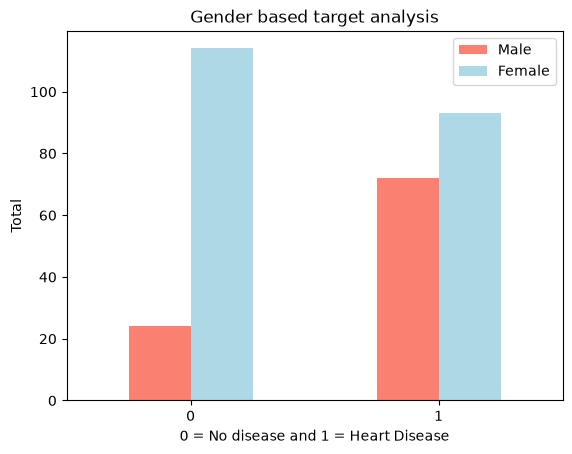

In [74]:
# visualize using matplotib 
x_data = pd.crosstab(df.target, df.sex)

# setting the lagend handler
legend_handles=[
    Patch(facecolor="salmon", label="Male"),
    Patch(facecolor="lightblue", label="Female"),
]

graph_logic.bar_plot(x_data,
                    x_label="0 = No disease and 1 = Heart Disease",
                    y_label="Total",
                    graph_title="Gender based target analysis",
                    labels=legend_handles,
                    colors=['salmon', 'lightblue'],
                    file_name_to_save="../images/eda/002_gender_based_heart_disease_analysis.png")


### let's compare : Age vs Max Heart rate (Thelach) with the target


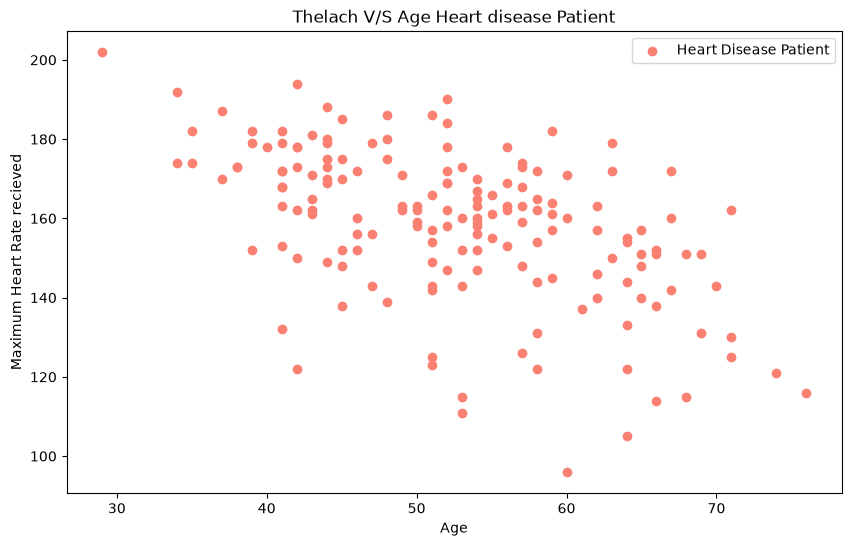

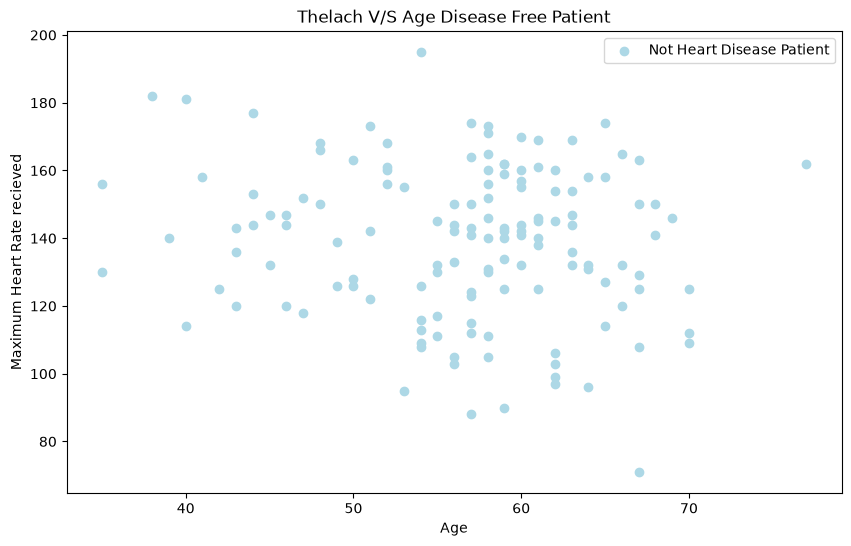

In [75]:
graph_logic.scatter_plot(x_data=df.age[df.target==1],
            y_data=df.thalach[df.target==1],
            graph_title="Thelach V/S Age Heart disease Patient",
            x_label="Age",
            y_label="Maximum Heart Rate recieved",
            labels=["Heart Disease Patient"],
            file_name_to_save="../images/eda/004_thelach_age_heart_patient.png")

graph_logic.scatter_plot(x_data=df.age[df.target==0],
            y_data=df.thalach[df.target==0],
            graph_title="Thelach V/S Age Disease Free Patient",
            x_label="Age",
            y_label="Maximum Heart Rate recieved",
            labels=["Not Heart Disease Patient"],
            colors="lightblue",
            file_name_to_save="../images/eda/005_thelach_age_not_heart_patient.png")

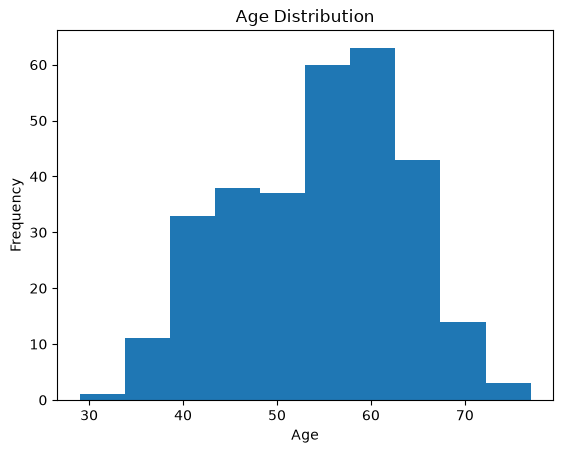

In [76]:
# let find the age histogram 
df.age.plot.hist()
plt.title("Age Distribution")
plt.xlabel("Age");

# save the graph 
plt.savefig("../images/eda/003_age_distribution.png")

### Heart Disease Frequency per Chest Pain Type
`cp` - Chest Pain type
* 0 : typical angina 
* 1 : atypical angina
* 2 : non-anginal
* 3 : asymptomatic

In [52]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


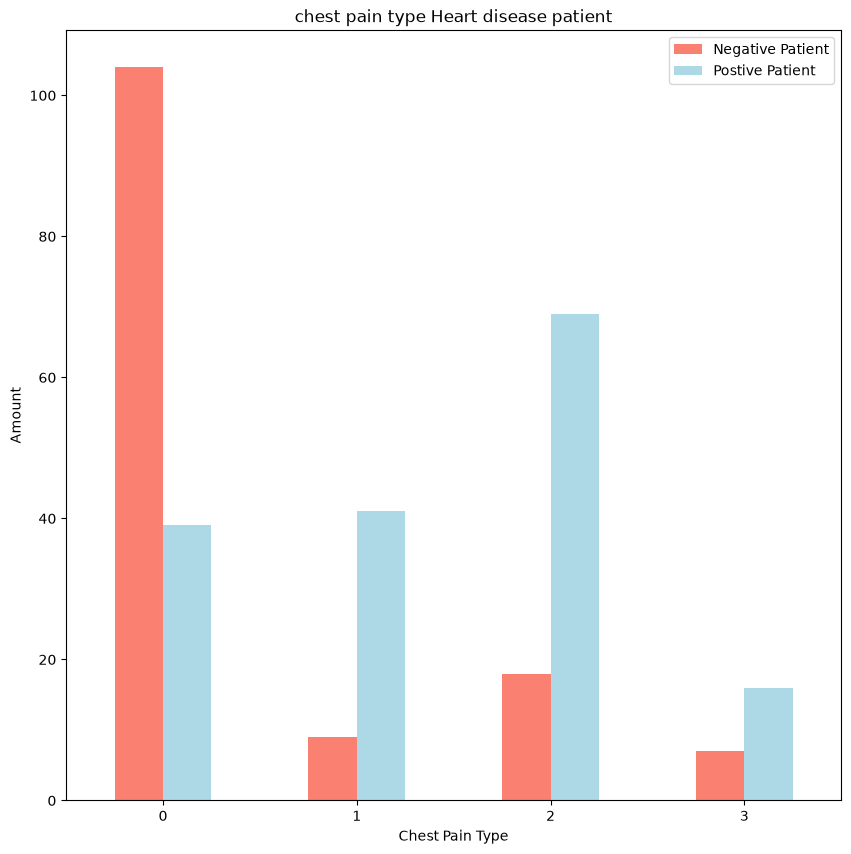

In [72]:
x_data = pd.crosstab(df.cp,
                    df.target)

# legends handling 
legend_handles=[
    Patch(facecolor="salmon", label="Negative Patient"),
    Patch(facecolor="lightblue", label="Postive Patient")
]

graph_logic.bar_plot(x_data=x_data,
                    graph_title="chest pain type Heart disease patient",
                    x_label="Chest Pain Type",
                    y_label="Amount",
                    figsize=(10, 10),
                    labels=legend_handles, 
                    colors=['salmon', 'lightblue'],
                    file_name_to_save="../images/eda/006_heart_disease_chest_pain_type.png")

In [71]:
importlib.reload(graph_logic)

<module 'utility.graph_logic' from 'F:\\personal\\Projects\\heart-disease-project\\src\\utility\\graph_logic.py'>